In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

plt.style.use('dark_background')
print("Рабочая директория:", os.getcwd())

Рабочая директория: d:\Libraries\Documents\VScode\CV_labs_Plotnikov_8E21\Lab_2


Загружено: 2.jpg
Загружено: 3.jpg
Загружено: 4.jpg
Загружено: 5.jpg
Загружено: 6.jpg
Загружено: 7.jpg
Загружено: 8.jpg
Загружено: 9.jpg


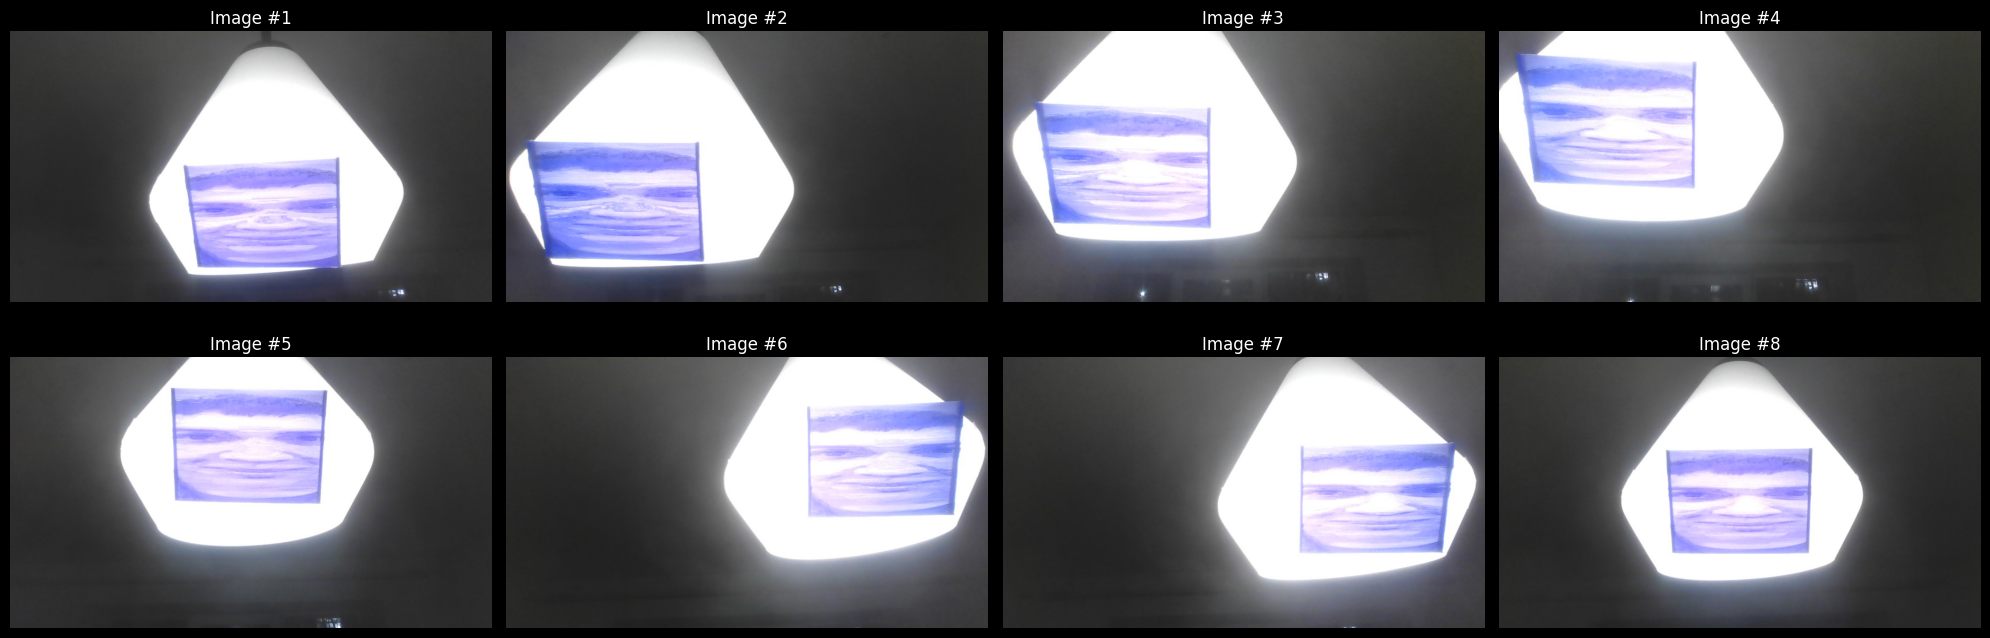

In [22]:
# ==========================================
# 1. ЗАГРУЗКА ИЗОБРАЖЕНИЙ
# ==========================================

# Путь к папке с 8 фотографиями
data_path = 'D:\Libraries\Documents\VScode\CV_labs_Plotnikov_8E21\Lab_2\Pictures'

# Список для хранения изображений
images = []
images_gray = []

# Загружаем 8 изображений (имена: 1.jpg, 2.jpg ... 8.jpg)
for i in range(1, 9):
    filename = f"{i+1}.jpg"
    filepath = os.path.join(data_path, filename)
    
    if os.path.exists(filepath):
        img = cv2.imread(filepath)
        # Переводим в RGB для вывода
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Переводим в Grayscale для математики
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        images.append(img_rgb)
        images_gray.append(img_gray)
        print(f"Загружено: {filename}")
    else:
        print(f"Не найдено: {filename}. Проверьте путь.")

# Визуализация загруженных фото
if len(images) == 8:
    plt.figure(figsize=(20, 7))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i])
        plt.title(f"Image #{i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"Загружено только {len(images)} изображений. Продолжаем с тем, что есть.")

In [23]:
# ==========================================
# 1. ФУНКЦИЯ РУЧНОЙ СВЕРТКИ (для градиентов)
# ==========================================

def manual_convolve(image, kernel):
    """
    Выполняет 2D свертку изображения с ядром вручную.
    Используется для вычисления градиентов.
    """
    k_size = kernel.shape[0]
    pad = k_size // 2
    
    # Паддинг изображения (копируем края, чтобы сохранить размер)
    padded_img = np.pad(image, pad, mode='edge')
    
    h, w = image.shape
    result = np.zeros((h, w))
    
    # Проходим по каждому пикселю (без использования встроенных сверток)
    for i in range(h):
        for j in range(w):
            region = padded_img[i:i+k_size, j:j+k_size]
            result[i, j] = np.sum(region * kernel)

    return result

In [24]:
# ==========================================
# 2. ПРИМЕНЕНИЕ К ИЗОБРАЖЕНИЯМ
# ==========================================

# Определяем ядра Собеля (Sobel Kernels)
# Ядро для оси X (вертикальные границы)
kernel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Ядро для оси Y (горизонтальные границы)
kernel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

# Списки для хранения результатов
gradients_x = []
gradients_y = []
magnitudes = []

# Берем одно изображение для проверки (например, первое)
img_idx = 7 
img_gray = images_gray[img_idx]

# Вычисляем градиенты вручную
dx = manual_convolve(img_gray, kernel_x)
dy = manual_convolve(img_gray, kernel_y)

# Вычисляем магнитуду (силу) градиента: sqrt(dx^2 + dy^2)
# Это покажет все границы, независимо от направления
magnitude = np.sqrt(dx**2 + dy**2)

gradients_x.append(dx)
gradients_y.append(dy)
magnitudes.append(magnitude)

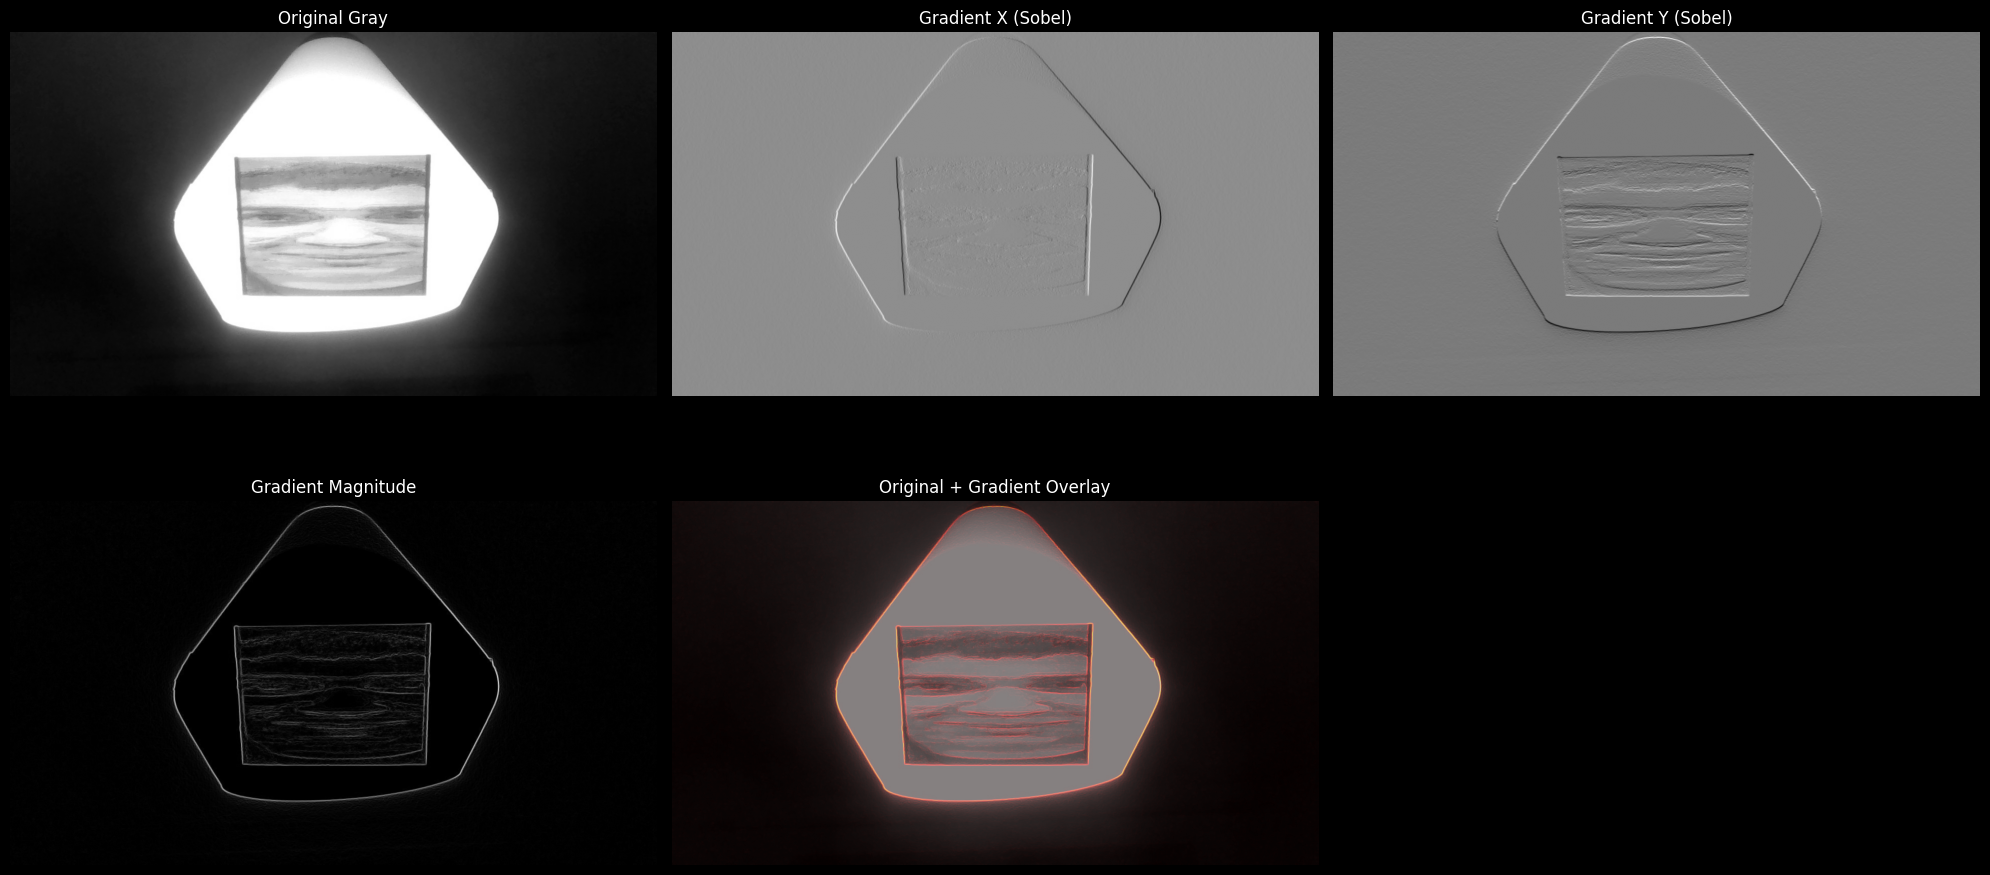

Средняя сила градиента на изображении: 9.09


In [25]:
# ==========================================
# 3. ВИЗУАЛИЗАЦИЯ
# ==========================================
plt.figure(figsize=(20, 10))
size_x = 3
size_y = 2
# 1. Оригинал
plt.subplot(size_y, size_x, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Gray")
plt.axis('off')

# 2. Градиент X (вертикальные края)
plt.subplot(size_y, size_x, 2)
plt.imshow(dx, cmap='gray')
plt.title("Gradient X (Sobel)")
plt.axis('off')

# 3. Градиент Y (горизонтальные края)
plt.subplot(size_y, size_x, 3)
plt.imshow(dy, cmap='gray')
plt.title("Gradient Y (Sobel)")
plt.axis('off')

# 4. Магнитуда (все края)
plt.subplot(size_y, size_x, 4)
plt.imshow(magnitude, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis('off')

# 5. Оригинал с наложением (для наглядности)
# Умножим магнитуду на 255/max для нормализации
mag_norm = (magnitude / magnitude.max() * 255).astype(np.uint8)
plt.subplot(size_y, size_x, 5)
plt.imshow(img_gray, cmap='gray')
# Используем альфа-канал, чтобы наложить градиенты (опционально)
# Или просто покажем нормализованную магнитуду
plt.imshow(magnitude, cmap='hot', alpha=0.5) 
plt.title("Original + Gradient Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Средняя сила градиента на изображении: {np.mean(magnitude):.2f}")

In [26]:
# ==========================================
# 1. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (из методички)
# ==========================================
def local_max(response_map, window_size):
    """Поиск локальных максимумов в карте отклика"""
    pad = window_size // 2
    h, w = response_map.shape
    corners_dict = {}
    
    for i in range(pad, h - pad):
        for j in range(pad, w - pad):
            window = response_map[i-pad:i+pad+1, j-pad:j+pad+1]
            # Если текущий пиксель - максимум в окне
            if response_map[i, j] == np.max(window) and response_map[i, j] > 0:
                # Сохраняем значение отклика и координаты (x, y)
                corners_dict[response_map[i, j]] = [j, i]
                
    return corners_dict

# ==========================================
# 2. ОСНОВНОЙ ДЕТЕКТОР УГЛОВ
# ==========================================
def manual_corner_detect(img_gray, n_corners=20, window_size=5):
    """
    Определяет ключевые точки на изображении.
    Возвращает массив координат [[x1, y1], [x2, y2], ...]
    """
    # Для подавления шума используем готовый GaussianBlur (разрешено методичкой)
    # Если нужно полностью вручную, можно заменить на manual_convolve с ядром Гаусса
    img_blur = cv2.GaussianBlur(img_gray, (5, 5), 1.5)
    
    # Вычисляем градиенты (можно использовать np.gradient или наши Sobel-ядра)
    dy, dx = np.gradient(img_blur)
    
    # Окно усреднения для матрицы структуры
    window = np.ones((window_size, window_size))
    
    # Вычисляем компоненты матрицы структуры M = [Ix^2, IxIy; IxIy, Iy^2]
    c_xx = manual_convolve(dx * dx, window)
    c_yy = manual_convolve(dy * dy, window)
    c_xy = manual_convolve(dx * dy, window)
    
    h, w = img_blur.shape
    response_map = np.zeros((h, w))
    
    # Вычисляем отклик угла для каждого пикселя
    # Методичка использует min(eigenvalues) как критерий "угловатости"
    for i in range(h):
        for j in range(w):
            M = np.array([[c_xx[i, j], c_xy[i, j]], 
                          [c_xy[i, j], c_yy[i, j]]])
            eigenvalues, _ = np.linalg.eig(M)
            response_map[i, j] = np.min(eigenvalues)
            
    # Находим локальные максимумы
    corners_dict = local_max(response_map, window_size)
    
    # Сортируем по значению отклика (по убыванию) и берем top-N
    sorted_corners = sorted(corners_dict.items(), key=lambda x: x[0], reverse=True)
    top_corners = [coord for _, coord in sorted_corners[:n_corners]]
    
    return np.array(top_corners)

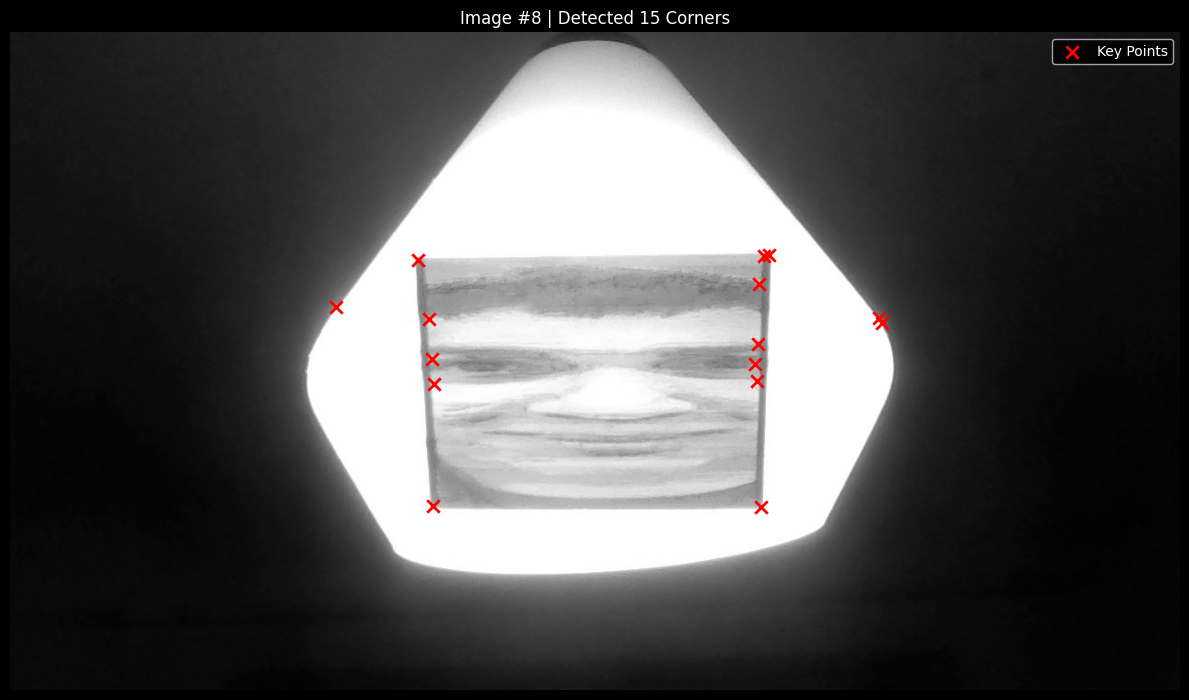

Координаты найденных точек (x, y):
[[830 244]
 [446 249]
 [462 518]
 [819 275]
 [821 519]
 [461 357]
 [356 301]
 [458 314]
 [817 381]
 [818 341]
 [824 245]
 [463 385]
 [953 318]
 [950 312]
 [814 363]]


In [27]:
# ==========================================
# 3. ПРИМЕНЕНИЕ И ВИЗУАЛИЗАЦИЯ
# ==========================================
# Возьмем первое изображение для демонстрации
img_idx = 7
img_test = images_gray[img_idx]

# Находим 15 самых сильных углов
corners = manual_corner_detect(img_test, n_corners=15, window_size=5)

# Визуализация
plt.figure(figsize=(12, 8))
plt.imshow(img_test, cmap='gray')

if len(corners) > 0:
    pts_x = corners[:, 0]
    pts_y = corners[:, 1]
    plt.scatter(pts_x, pts_y, c='red', s=80, marker='x', linewidths=2, label='Key Points')
    plt.legend()

plt.title(f"Image #{img_idx+1} | Detected {len(corners)} Corners")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Координаты найденных точек (x, y):\n{corners}")

In [28]:
# ==========================================
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ: Свертка (из методички)
# ==========================================
def convolution(image, window):
    """Ручная свертка изображения с окном"""
    start = int((window.shape[0]-1)/2)
    result = np.zeros(image.shape)
    # Используем padding для обработки краев
    padded = np.pad(image, start, mode='edge')
    
    for i in range(start, padded.shape[0]-start):
        for j in range(start, padded.shape[1]-start):
            # Извлекаем фрагмент и умножаем на окно
            fragment = padded[i-start : i+start+1, j-start : j+start+1]
            result[i-start, j-start] = np.sum(fragment * window)
    return result

# ==========================================
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ: Локальные максимумы
# ==========================================
def local_max(e, window_size):
    """Находит локальные максимумы в карте отклика 'e'"""
    start = int((window_size-1)/2)
    result = np.zeros(e.shape)
    corner_dict = dict() # Словарь {значение_отклика: [x, y]}
    
    # Проходим по внутренним пикселям (чтобы было окно вокруг)
    for i in range(start, e.shape[0]-start):
        for j in range(start, e.shape[1]-start):
            # Окно вокруг пикселя
            neighborhood = e[i-start : i+start+1, j-start : j+start+1]
            
            # Если текущий пиксель - максимум в своем окне
            if e[i, j] == np.max(neighborhood):
                corner_dict[e[i, j]] = [j, i] # Сохраняем как [x, y]
    return corner_dict

# ==========================================
# ОСНОВНАЯ ФУНКЦИЯ: Поиск углов
# ==========================================
def corner_detect(image_gray, n_corners, window_size):
    """
    Детектор углов (аналог Харриса).
    image_gray: изображение в оттенках серого
    n_corners: количество лучших точек для возврата
    window_size: размер окна для анализа
    """
    
    # 1. Сглаживание для уменьшения шума (методичка рекомендует)
    # Используем Гаусс (это разрешено как базовая операция)
    gauss_img = cv2.GaussianBlur(image_gray, (5, 5), 1.5)
    
    # 2. Градиенты (изменение яркости)
    dy, dx = np.gradient(gauss_img)
    
    # 3. Компоненты матрицы структуры
    # В методичке: c_xx, c_yy, c_xy
    # Мы свертываем их с единичным окном, чтобы усреднить значения в окрестности
    window = np.ones((window_size, window_size))
    
    c_xx = convolution(dx*dx, window)
    c_yy = convolution(dy*dy, window)
    c_xy = convolution(dx*dy, window)
    
    # 4. Вычисление отклика (Eigenvalues)
    # В методичке используется цикл с np.linalg.eig, но это очень медленно.
    # Математически собственные числа матрицы 2x2 находятся через корни характеристического уравнения.
    # Lambda = (Trace +/- sqrt(Trace^2 - 4*Det)) / 2
    # Нам нужно минимальное (min_lambda).
    
    trace = c_xx + c_yy
    det = (c_xx * c_yy) - (c_xy * c_xy)
    
    # Формула для минимального собственного числа
    discriminant = trace**2 - 4 * det
    # Защита от отрицательного дискриминанта из-за шумов (берем 0)
    discriminant = np.maximum(discriminant, 0)
    
    e = (trace - np.sqrt(discriminant)) / 2
    
    # 5. Поиск локальных максимумов
    corner_dict = local_max(e, window_size)
    
    # 6. Сортировка и выбор топ-N
    # Сортируем ключи (значения отклика) по убыванию
    sorted_keys = sorted(corner_dict.keys(), reverse=True)
    
    corners = []
    for key in sorted_keys:
        corners.append(corner_dict[key])
        if len(corners) >= n_corners:
            break
            
    return np.array(corners)

Найдено 30 углов.


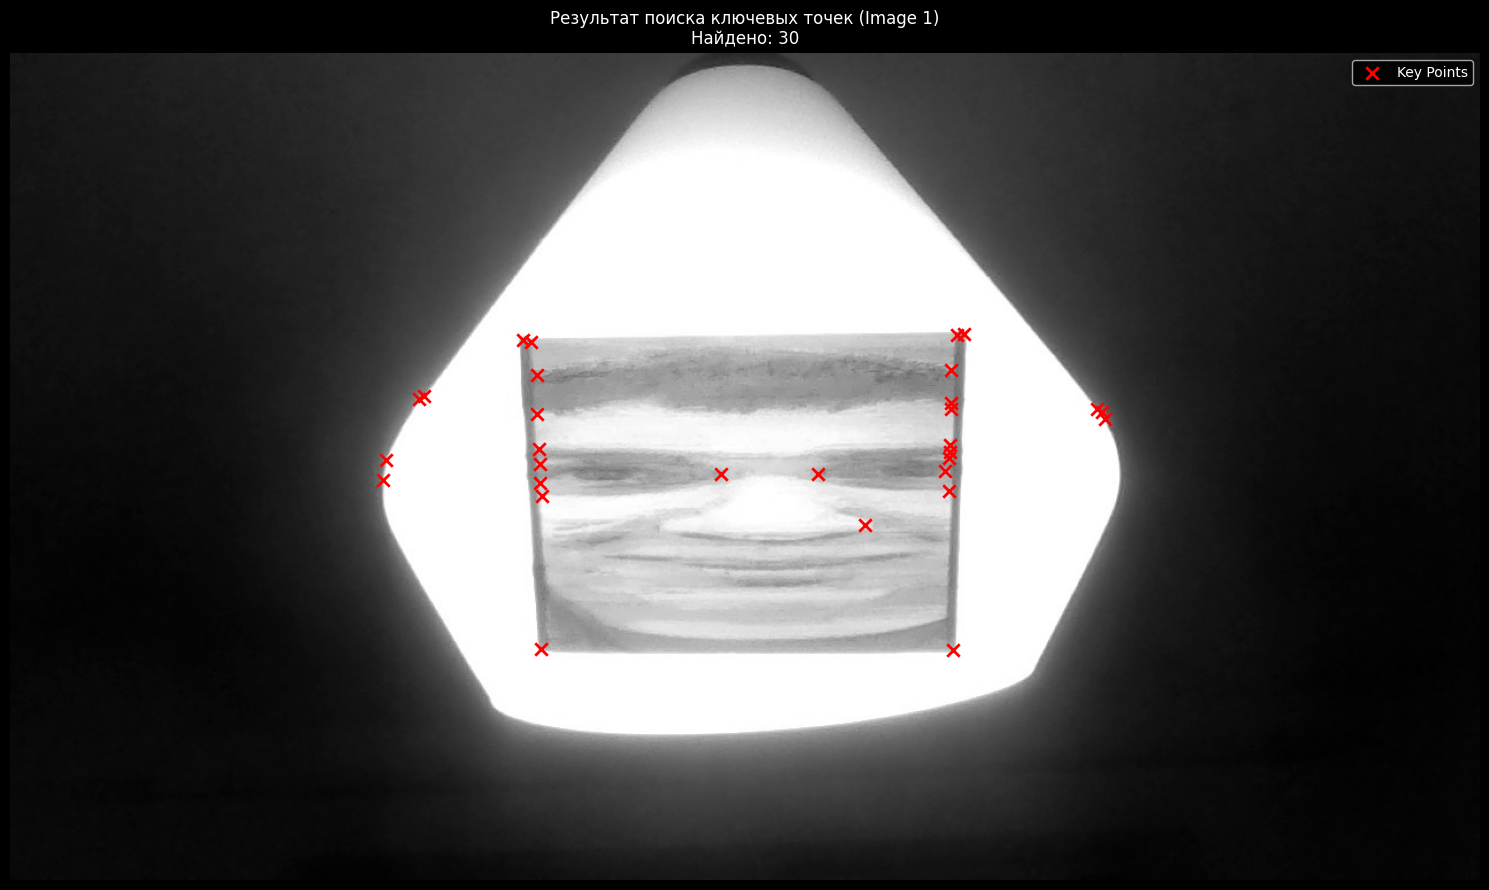

In [30]:
# ==========================================
# ПРИМЕНЕНИЕ И ПРОВЕРКА
# ==========================================

# Берем одно из загруженных изображений (например, первое)
# Предполагаем, что images_gray[0] существует из предыдущего шага
test_img = images_gray[7]

# Ищем 30 лучших углов
# window_size=5 означает, что мы анализируем окно 5x5 пикселей вокруг точки
found_corners = corner_detect(test_img, n_corners=30, window_size=5)

print(f"Найдено {len(found_corners)} углов.")

# Визуализация
plt.figure(figsize=(15, 10))
plt.imshow(test_img, cmap='gray')

if len(found_corners) > 0:
    # scatter рисует точки. found_corners[:, 0] это X, found_corners[:, 1] это Y
    plt.scatter(found_corners[:, 0], found_corners[:, 1], 
                c='red', s=80, marker='x', linewidths=2, label='Key Points')
    plt.legend()

plt.title(f"Результат поиска ключевых точек (Image 1)\nНайдено: {len(found_corners)}")
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (из методички)
# ==========================================
def local_max(e, window_size):
    """Поиск локальных максимумов в карте отклика (e)"""
    start = int((window_size-1)/2)
    corner = dict()
    
    # Проходим по внутренним пикселям (пропуская края размером с окно)
    for i in range(start, e.shape[0]-start):
        for j in range(start, e.shape[1]-start):
            # Вырезаем окно вокруг текущего пикселя
            x = e[i-start : i+start+1, j-start : j+start+1]
            
            # Если центральный пиксель равен максимуму в этом окне — это кандидат
            if (e[i, j] == np.max(x)):
                corner[e[i, j]] = [j, i] # Сохраняем координаты в формате [x, y]
    return corner

def corner_detect(image_gray, n_corners, window_size):
    """
    Главный детектор ключевых точек.
    image_gray: серое изображение
    n_corners: сколько лучших точек вернуть
    window_size: размер окна анализа
    """
    # 1. Сглаживание (убираем шум перед вычислением градиентов)
    gauss_img = cv2.GaussianBlur(image_gray, (5, 5), 3)
    
    # 2. Градиенты (изменение яркости по X и Y)
    dy, dx = np.gradient(gauss_img)
    
    # 3. Создаем окно усреднения
    window = np.ones((window_size, window_size))
    
    # 4. Вычисляем компоненты матрицы структуры (c_xx, c_yy, c_xy)
    # Сворачиваем произведения градиентов с окном
    c_xx = convolution(dx*dx, window)
    c_yy = convolution(dy*dy, window)
    c_xy = convolution(dx*dy, window)
    
    # 5. Вычисляем карту отклика (Eigenvalues)
    e = np.zeros(gauss_img.shape)
    
    # Методичка рекомендует цикл по пикселям для нахождения собственных чисел
    for i in range(gauss_img.shape[0]):
        for j in range(gauss_img.shape[1]):
            # Матрица 2x2 для текущего пикселя
            M = np.array([[c_xx[i, j], c_xy[i, j]], 
                          [c_xy[i, j], c_yy[i, j]]])
            
            # Находим собственные числа
            l, v = np.linalg.eig(M)
            
            # Критерий "угловатости" — минимальное собственное число
            e[i, j] = np.min(l)
            
    # 6. Находим локальные максимумы
    corner = local_max(e, window_size)
    
    # 7. Сортируем по силе отклика (по убыванию) и берем топ-N
    corners = []
    for key in sorted(corner.keys(), reverse=True):
        corners.append(corner[key])
        if len(corners) >= n_corners:
            break
            
    return np.array(corners)

# ==========================================
# ПРИМЕНЕНИЕ И ВИЗУАЛИЗАЦИЯ
# ==========================================

# Берем первое изображение из загруженных (images_gray[0])
# Убедитесь, что переменная images_gray существует из предыдущего шага
test_image = images_gray[0]

# Ищем 30 лучших углов с окном 5x5
key_points = corner_detect(test_image, n_corners=30, window_size=5)

print(f"Найдено {len(key_points)} ключевых точек.")

# Визуализация
plt.figure(figsize=(15, 10))
plt.imshow(test_image, cmap='gray')

if len(key_points) > 0:
    # key_points содержит [x, y]
    plt.scatter(key_points[:, 0], key_points[:, 1], c='red', s=80, marker='x', linewidths=2)
    
plt.title(f"Результат работы детектора углов (Image 1)\nНайдено точек: {len(key_points)}")
plt.axis('off')
plt.tight_layout()
plt.show()